# Q-Function Corrector v2 (Predict-Correct-Perturb)


**Session flow (every session):**
1. Run §0 (config), §1 (setup), §2 (imports), §3 (policy), §4 (LIBERO-Pro)
2. Run §5 (collection) — resume-safe; ep_idx 0..N_EPISODES_TRAIN-1 only
3. Run §6–§10 (dataset → train → calibrate → gradient sanity check)
4. Run §11 (live eval: baseline pass then corrected pass; ep_idx N_EPISODES_TRAIN..+N_EPISODES_EVAL-1)
5. Run §12 (quantitative results) and §13 (video qual eval)


## §0 — Config

In [54]:
from google.colab import drive
import os, sys, subprocess, importlib, shutil, time as _setup_time

drive.mount('/content/drive')

DRIVE       = '/content/drive/MyDrive'
SHARED      = f'{DRIVE}/cs159_jeff'
CACHE_DIR   = f'{SHARED}/smolvla_colab_cache'
HF_HOME     = f'{CACHE_DIR}/hf_models'
RESULTS_DIR = f'{SHARED}/libero_pro_results'
QC_DIR      = f'{RESULTS_DIR}/q_corrector_v2'
QC_DB       = f'{QC_DIR}/qc_v2.db'
QC_CKPT     = f'{QC_DIR}/q_corrector_v2.pt'

# Jennifer's DB — primary training source (large, diverse, pre-collected)
JEN_DB = f'{RESULTS_DIR}/rollouts_jeff_dimensional.db'

os.makedirs(QC_DIR, exist_ok=True)
os.makedirs(HF_HOME, exist_ok=True)
os.environ['HF_HOME']               = HF_HOME
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['MUJOCO_GL']             = 'egl'

HF_TOKEN    = ''
POLICY_REPO = 'lerobot/pi05_libero_finetuned'
TOKENIZER   = 'google/paligemma-3b-pt-224'

CAMERAS        = ['agentview', 'robot0_eye_in_hand']
IMG_SIZE       = 360
NUM_STEPS_WAIT = 10
DUMMY_ACTION   = [0.0] * 6 + [-1.0]

SUITES = [
      'libero_object_temp_x0.1',   # ~53% SR
      'libero_object_temp_y0.1',   # ~60% SR
      'libero_object_temp_y0.2',   # ~27% SR
      'libero_90',                 # already registered, diverse, ~70% SR
]

N_TASKS          = 10
# ep_idx 0..N_EPISODES_TRAIN-1  → §5 collection (training augmentation, action-only)
# ep_idx N_EPISODES_TRAIN..+N_EPISODES_EVAL-1  → §11 eval only (never used in training)
N_EPISODES_TRAIN = 5
N_EPISODES_EVAL  = 10
MAX_STEPS        = 300

PNP_STEP_INDICES        = tuple(range(10))  # collect at all denoising steps
TRAIN_STEP_INDICES      = tuple(range(10))  # train on all steps
CORRECTION_STEP_INDICES = (7, 8)            # apply gradient correction only at late steps
PNP_K            = 3
ACTION_DIM       = 7

SEED         = 42
TRAIN_FRAC   = 0.80
LR           = 3e-4
WEIGHT_DECAY = 1e-4
EPOCHS       = 100
PATIENCE     = 20
BATCH_SIZE   = 256
LAMBDA_LIVE  = 0.5      # confirmed optimal from gradient sanity (Δf failure >> Δf success)

print(f'QC dir: {QC_DIR}')
print(f'DB:     {QC_DB}')
print(f'JEN_DB: {JEN_DB}  exists={os.path.exists(JEN_DB)}')
print(f'Suites: {SUITES}  ({N_TASKS} tasks × {N_EPISODES_TRAIN} train + {N_EPISODES_EVAL} eval episodes)')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
QC dir: /content/drive/MyDrive/cs159_jeff/libero_pro_results/q_corrector_v2
DB:     /content/drive/MyDrive/cs159_jeff/libero_pro_results/q_corrector_v2/qc_v2.db
JEN_DB: /content/drive/MyDrive/cs159_jeff/libero_pro_results/rollouts_jeff_dimensional.db  exists=True
Suites: ['libero_object_temp_x0.1', 'libero_object_temp_y0.1', 'libero_object_temp_y0.2', 'libero_90']  (10 tasks × 5 train + 10 eval episodes)


## §1 — System Setup

Run every session. Restores packages from Drive snapshot (~2 min) or does a full install on first use.

In [2]:
import subprocess, torch
print(subprocess.run(['nvidia-smi','--query-gpu=name,memory.total','--format=csv,noheader'],
                     capture_output=True, text=True).stdout.strip())
print(f'CUDA: {torch.cuda.is_available()}')


NVIDIA L4, 23034 MiB
CUDA: True


In [3]:
%%bash
apt-get update -qq
apt-get install -y -qq libosmesa6-dev libgl1-mesa-glx libglfw3 libglew-dev libegl1-mesa-dev patchelf ffmpeg
mkdir -p /usr/share/glvnd/egl_vendor.d
echo '{"file_format_version":"1.0.0","ICD":{"library_path":"libEGL_nvidia.so.0"}}' \
    > /usr/share/glvnd/egl_vendor.d/10_nvidia.json
echo 'System deps done'


System deps done


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [4]:
SNAPSHOT = f'{CACHE_DIR}/site_packages.tar.gz'

if os.path.exists(SNAPSHOT):
    print(f'Snapshot found ({os.path.getsize(SNAPSHOT)/1e6:.0f} MB) — restoring...')
    local_snap = '/content/site_packages_restore.tar.gz'
    t0 = _setup_time.time()
    shutil.copy(SNAPSHOT, local_snap)
    subprocess.run(['tar', '-xzf', local_snap, '-C', '/'], capture_output=True)
    os.remove(local_snap)
    importlib.invalidate_caches()
    print(f'Restored in {_setup_time.time()-t0:.1f}s')
    for pkg in ['mujoco', 'robosuite', 'libero', 'lerobot']:
        try:
            importlib.import_module(pkg); print(f'  {pkg} OK')
        except ImportError as e:
            print(f'  {pkg} MISSING: {e}')
else:
    print('No snapshot found. Running full install (~15 min)...')
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '-q',
        'mujoco', 'robosuite', 'libero', 'sentencepiece', 'tiktoken',
        'transformers==5.5.4',
        'lerobot[pi0] @ git+https://github.com/huggingface/lerobot.git@01dcb4c29222bc9f2388cebf87f0e79965a9508b',
    ])
    importlib.invalidate_caches()
    print('Install done.')


# torchao conflicts with this torch version via diffusers → lerobot import chain.
subprocess.run([sys.executable, '-m', 'pip', 'uninstall', 'torchao', '-y'],
               capture_output=True)
importlib.invalidate_caches()
print('torchao removed (incompatible with this torch build)')


Snapshot found (11198 MB) — restoring...
Restored in 276.4s


[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /usr/local/lib/python3.12/dist-packages/robosuite/scripts/setup_macros.py (__init__.py:9)


  mujoco OK
  robosuite OK
  libero OK
  lerobot OK
torchao removed (incompatible with this torch build)


## §2 — Imports

In [5]:
import json as _json
import sqlite3
import hashlib
import time as _time
import random
import types
from collections import defaultdict
from dataclasses import dataclass
from functools import partial

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.metrics as skm
from sklearn.calibration import calibration_curve

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')


Device: cuda


In [6]:
# ── Torch compatibility patches ───────────────────────────────────────────
import os, torch
os.environ['TORCHDYNAMO_DISABLE'] = '1'
import torch._dynamo
torch._dynamo.config.disable = True

import torch.ao.quantization as _taoq
for _name, _val in [('CUSTOM_KEY', 'custom'),
                    ('NUMERIC_DEBUG_HANDLE_KEY', 'numeric_debug_handle')]:
    if not hasattr(_taoq, _name):
        setattr(_taoq, _name, _val)

if not hasattr(torch, '_libero_true_load'):
    torch._libero_true_load = torch.load
def _patched_load(*args, **kwargs):
    kwargs.setdefault('weights_only', False)
    return torch._libero_true_load(*args, **kwargs)
torch.load = _patched_load
print('Patches applied.')

Patches applied.


## §3 — Policy Loading

In [7]:
import math, torch, types
from transformers import AutoTokenizer
from lerobot.policies.pi05.modeling_pi05 import PI05Policy
from lerobot.policies.factory import make_pre_post_processors
from huggingface_hub import login

if HF_TOKEN:
    login(token=HF_TOKEN)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# torch.compile triggers a broken torch._inductor import on this Colab build.
# Stub it out for model load — we replace sample_actions with our own patch anyway.
_orig_compile = torch.compile
torch.compile = lambda fn, *a, **kw: fn

policy = PI05Policy.from_pretrained(POLICY_REPO).to(device).eval()

torch.compile = _orig_compile  # restore

tokenizer = AutoTokenizer.from_pretrained(TOKENIZER)
print(f'PI05 loaded — {sum(p.numel() for p in policy.parameters())/1e6:.0f}M params on {device}')

preprocess, postprocess = make_pre_post_processors(
    policy.config, POLICY_REPO,
    preprocessor_overrides={'device_processor': {'device': str(device)}},
)

CHUNK_SIZE  = policy.config.chunk_size
MAX_ACT_DIM = policy.config.max_action_dim
DEVICE      = device
print(f'chunk_size={CHUNK_SIZE}  max_action_dim={MAX_ACT_DIM}')


def _quat2axisangle(quat):
    import math
    if quat[3] > 1.0:  quat[3] = 1.0
    elif quat[3] < -1.0: quat[3] = -1.0
    den = np.sqrt(1.0 - quat[3] ** 2)
    if math.isclose(den, 0.0): return np.zeros(3)
    return (quat[:3] * 2.0 * math.acos(quat[3])) / den


def obs_to_policy(obs_dict, task_desc):
    agentview = np.ascontiguousarray(obs_dict['agentview_image'][::-1, ::-1])
    wrist     = np.ascontiguousarray(obs_dict['robot0_eye_in_hand_image'][::-1, ::-1])
    state = np.concatenate([
        obs_dict['robot0_eef_pos'],
        _quat2axisangle(obs_dict['robot0_eef_quat']),
        obs_dict['robot0_gripper_qpos'],
    ])
    return {
        'observation.images.image':  torch.from_numpy(agentview / 255.0).permute(2, 0, 1).float(),
        'observation.images.image2': torch.from_numpy(wrist / 255.0).permute(2, 0, 1).float(),
        'observation.state':         torch.from_numpy(state).float(),
        'task':                      task_desc,
    }


def get_encodings(obs_dict, task_desc):
    batch = preprocess(obs_to_policy(obs_dict, task_desc))
    images, _ = policy._preprocess_images(batch)
    img_encs = []
    for img in images:
        with torch.no_grad():
            enc = policy.model.paligemma_with_expert.embed_image(img)
        img_encs.append(enc.mean(dim=1).squeeze(0).cpu().float().numpy())
    obs_enc = np.concatenate(img_encs)

    tok = tokenizer(task_desc, return_tensors='pt', truncation=True, max_length=64).to(device)
    with torch.no_grad():
        lang_emb = policy.model.paligemma_with_expert.embed_language_tokens(tok['input_ids'])
    lang_enc = lang_emb.mean(dim=1).squeeze(0).cpu().float().numpy()
    return obs_enc, lang_enc

The PI05 model is a direct port of the OpenPI implementation. 
This implementation follows the original OpenPI structure for compatibility. 
Original implementation: https://github.com/Physical-Intelligence/openpi


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading model from: lerobot/pi05_libero_finetuned


✓ Loaded state dict from model.safetensors
All keys loaded successfully!
PI05 loaded — 4143M params on cuda
chunk_size=50  max_action_dim=32


## §4 — LIBERO-Pro Registration

Builds a `bm_dict` that maps suite names to callable factories (returns `ProLiberoSuite`).
Extracts bddl/init files from Drive cache for Pro suites; standard LIBERO suites work out of the box.

In [8]:
import sys, tarfile, shutil, importlib
from libero.libero import get_libero_path
from libero.libero.benchmark import get_benchmark_dict

LIBERO_SITE    = f'/usr/local/lib/python3.{sys.version_info.minor}/dist-packages/libero/libero'
BDDL_FILES_DIR = os.path.join(LIBERO_SITE, 'bddl_files')
INIT_FILES_DIR = os.path.join(LIBERO_SITE, 'init_files')
PRO_CACHE      = f'{CACHE_DIR}/libero_pro_files.tar.gz'
PRO_INIT_BACKUP = f'{RESULTS_DIR}/init_files_backup_dimensional_1'

# ── Step 1: Download pro suite bddl files from HuggingFace if missing ────────
PRO_SUITES_MISSING = [s for s in SUITES
                      if not os.path.isdir(os.path.join(BDDL_FILES_DIR, s))]
if PRO_SUITES_MISSING:
    from huggingface_hub import snapshot_download
    print(f'Downloading pro bddl files for: {PRO_SUITES_MISSING}')
    _hf_tmp = '/tmp/libero_pro_bddl'
    snapshot_download(
        repo_id='zhouxueyang/LIBERO-Pro',
        repo_type='dataset',
        local_dir=_hf_tmp,
        allow_patterns=['bddl_files/**'],
    )
    for suite in PRO_SUITES_MISSING:
        src_dir = os.path.join(_hf_tmp, 'bddl_files', suite)
        dst_dir = os.path.join(BDDL_FILES_DIR, suite)
        if os.path.isdir(src_dir) and not os.path.isdir(dst_dir):
            shutil.copytree(src_dir, dst_dir)
            n = len([f for f in os.listdir(dst_dir) if f.endswith('.bddl')])
            print(f'  Copied bddl_files/{suite}: {n} tasks')
        else:
            print(f'  WARNING: {suite} not found in HF download at {src_dir}')
else:
    print('Pro bddl dirs already present.')

# ── Step 2: Restore init_files from Drive backup ──────────────────────────────
_pro_suites = [s for s in SUITES if s not in get_benchmark_dict()]
for suite in _pro_suites:
    src = os.path.join(PRO_INIT_BACKUP, suite)
    dst = os.path.join(INIT_FILES_DIR, suite)
    if os.path.exists(dst):
        print(f'  init_files/{suite}: already present ({len(os.listdir(dst))} files)')
        continue
    if os.path.exists(src):
        shutil.copytree(src, dst)
        n = len([f for f in os.listdir(dst) if f.endswith('.pruned_init')])
        print(f'  Restored init_files/{suite}: {n} init states')
    else:
        print(f'  WARNING: backup not found for {suite} at {src}')


def _load_init_states(path):
    if path.endswith('.pruned_init'):
        data = torch.load(path, weights_only=False)
        if isinstance(data, np.ndarray):
            return data
        if isinstance(data, dict):
            arrays = [v for v in data.values()
                      if isinstance(v, np.ndarray) and v.ndim > 0]
        else:
            arrays = [np.asarray(data)]
        return np.concatenate(arrays, axis=0) if len(arrays) > 1 else arrays[0]
    data = np.load(path, allow_pickle=True)
    if isinstance(data, np.ndarray):
        return data
    arrays = [data[k] for k in data.files
              if isinstance(data[k], np.ndarray) and data[k].ndim > 0]
    return arrays[0] if len(arrays) == 1 else np.concatenate(arrays, axis=0)


@dataclass
class _Task:
    language: str
    problem_folder: str
    bddl_file: str


class ProLiberoSuite:
    """Thin wrapper around bddl + init_files directories for pro/custom suites."""
    def __init__(self, suite_name, task_names):
        self.suite_name  = suite_name
        self._task_names = task_names
        # pro suite init files live in LIBERO_SITE/init_files/, not init_states/
        self._init_dir   = os.path.join(INIT_FILES_DIR, suite_name)

    def get_task(self, task_idx):
        name = self._task_names[task_idx]
        return _Task(language=name.replace('_', ' '),
                     problem_folder=self.suite_name,
                     bddl_file=f'{name}.bddl')

    def get_task_init_states(self, task_idx):
        name = self._task_names[task_idx]
        for path in [
            os.path.join(self._init_dir, f'{name}.pruned_init'),
            os.path.join(self._init_dir, f'{name}_demo.npy'),
            os.path.join(self._init_dir, f'{name}.npy'),
        ]:
            if os.path.exists(path):
                return _load_init_states(path)
        raise FileNotFoundError(f'No init state file for {name!r} in {self._init_dir}')

    @property
    def n_tasks(self):
        return len(self._task_names)


bm_dict = get_benchmark_dict()

for suite in SUITES:
    if suite in bm_dict:
        print(f'  {suite}: already registered')
        continue
    bddl_suite_dir = os.path.join(BDDL_FILES_DIR, suite)
    if not os.path.isdir(bddl_suite_dir):
        print(f'  {suite}: bddl dir not found — skipping')
        continue
    task_names = sorted(fn[:-5] for fn in os.listdir(bddl_suite_dir) if fn.endswith('.bddl'))
    if not task_names:
        print(f'  {suite}: no .bddl files found — skipping')
        continue
    bm_dict[suite] = (lambda s=suite, t=task_names: ProLiberoSuite(s, t))
    print(f'  {suite}: registered ({len(task_names)} tasks)')

missing = [s for s in SUITES if s not in bm_dict]
if missing:
    print(f'WARNING: suites not registered: {missing}')
else:
    print(f'\nbm_dict ready. Pro suites: {[s for s in SUITES if s in bm_dict]}')


Pro bddl dirs already present.
  init_files/libero_object_temp_x0.1: already present (20 files)
  init_files/libero_object_temp_y0.1: already present (20 files)
  init_files/libero_object_temp_y0.2: already present (20 files)
  libero_object_temp_x0.1: registered (10 tasks)
  libero_object_temp_y0.1: registered (10 tasks)
  libero_object_temp_y0.2: registered (10 tasks)
  libero_90: already registered

bm_dict ready. Pro suites: ['libero_object_temp_x0.1', 'libero_object_temp_y0.1', 'libero_object_temp_y0.2', 'libero_90']


## §5 — Data Collection

Uncertainty-mode P&P rollouts on all configured tasks (ep_idx 0..N_EPISODES_TRAIN-1).
Writes action chunk stats (`u_vec`, `a_mean_vec`, `chunk_pos`) to `qc_v2.db`.
Resume-safe: already-collected episodes are skipped.

**Note**: obs/lang encodings are NOT stored — action-only model, no embeddings needed.


In [9]:
_DDL = """
CREATE TABLE IF NOT EXISTS qc_rollouts (
    rollout_id       TEXT PRIMARY KEY,
    suite            TEXT,
    task_idx         INTEGER,
    episode_idx      INTEGER,
    task_desc        TEXT,
    init_state_hash  TEXT,
    success          INTEGER,
    n_steps          INTEGER,
    elapsed_s        REAL,
    chunks           TEXT,
    timestamp        TEXT
);
CREATE TABLE IF NOT EXISTS qc_eval_rollouts (
    rollout_id       TEXT PRIMARY KEY,
    suite            TEXT,
    task_idx         INTEGER,
    episode_idx      INTEGER,
    task_desc        TEXT,
    init_state_hash  TEXT,
    success          INTEGER,
    n_steps          INTEGER,
    elapsed_s        REAL,
    lambda_          REAL,
    step_indices     TEXT,
    timestamp        TEXT
);
"""

db_con = sqlite3.connect(QC_DB, check_same_thread=False)
db_con.executescript(_DDL); db_con.commit()
n_existing = db_con.execute('SELECT COUNT(*) FROM qc_rollouts').fetchone()[0]
print(f'DB ready: {QC_DB}  ({n_existing} existing train rollouts)')


def _make_train_rid(suite, task_idx, ep_idx, init_state):
    h   = hashlib.md5(np.asarray(init_state).tobytes()).hexdigest()[:12]
    steps = '_'.join(map(str, sorted(PNP_STEP_INDICES)))
    key = f'{suite}:{task_idx}:{ep_idx}:{h}:v5:steps={steps}'
    return hashlib.sha256(key.encode()).hexdigest()[:16]


def _episode_collected(con, table, rid):
    return con.execute(f'SELECT 1 FROM {table} WHERE rollout_id=?', (rid,)).fetchone() is not None


def _write_train_episode(con, rid, suite, task_idx, ep_idx, task_desc,
                         init_state, success, n_steps, elapsed_s, chunks_json):
    h = hashlib.md5(np.asarray(init_state).tobytes()).hexdigest()[:12]
    with con:
        con.execute(
            'INSERT OR IGNORE INTO qc_rollouts '
            '(rollout_id,suite,task_idx,episode_idx,task_desc,init_state_hash,'
            'success,n_steps,elapsed_s,chunks,timestamp) '
            'VALUES (?,?,?,?,?,?,?,?,?,?,?)',
            (rid, suite, task_idx, ep_idx, task_desc, h,
             int(success), n_steps, round(elapsed_s, 3),
             _json.dumps(chunks_json),
             _time.strftime('%Y-%m-%dT%H:%M:%S')))


DB ready: /content/drive/MyDrive/cs159_jeff/libero_pro_results/q_corrector_v2/qc_v2.db  (919 existing train rollouts)


In [10]:
# ── P&P uncertainty measurement patch ────────────────────────────────────
@dataclass
class PnPConfig:
    enabled:      bool  = True
    step_indices: tuple = PNP_STEP_INDICES
    num_iterations: int = PNP_K
    action_dim:   int   = ACTION_DIM

    def step_selected(self, step, s):
        return self.enabled and step in self.step_indices


_COLLECT_CFG     = PnPConfig()
_CHUNK_IDX       = [0]
_ALL_CHUNKS      = []          # list of (chunk_idx, step_rec)
_CURRENT_OBS_ENC = [None]      # set per chunk; shape (d_model,) numpy array


def _refine_uncertainty_only(x_t, s, vfield, cfg):
    """K P&P iterations; return x_t unchanged (measurement-only, no steering)."""
    adim = cfg.action_dim
    a_hats = []
    x_acc = x_t.clone()
    for _ in range(cfg.num_iterations):
        with torch.no_grad():
            v = vfield(x_acc)
        a_hat = x_acc - s * v
        a_hats.append(a_hat[..., :adim])
        x_acc = (1.0 - s) * a_hat + s * torch.randn_like(x_acc)

    A     = torch.stack(a_hats, dim=0)    # (K, B, T, adim)
    z_hat = A.mean(dim=0)[0]              # (T, adim) — mean over K iterations, batch 0

    obs_np = _CURRENT_OBS_ENC[0]
    rec = {
        'euler_step': 0,                  # filled by caller
        's':          float(s),
        'z_hat':      z_hat.detach().float().cpu().numpy().tolist(),   # list[T][adim]
        'obs_enc':    obs_np.tolist() if obs_np is not None else None, # list[d_model]
    }
    return x_t, rec


@torch.no_grad()
def _sample_actions_collect(self, images, img_masks, tokens, masks,
                             noise=None, num_steps=None, **kwargs):
    cfg = _COLLECT_CFG
    if num_steps is None: num_steps = self.config.num_inference_steps
    bsize  = tokens.shape[0]
    device = tokens.device
    if noise is None:
        noise = self.sample_noise(
            (bsize, self.config.chunk_size, self.config.max_action_dim), device)

    from lerobot.policies.pi05.modeling_pi05 import make_att_2d_masks
    prefix_embs, prefix_pad, prefix_att = self.embed_prefix(images, img_masks, tokens, masks)

    # store mean-pooled obs+lang encoding for Q(s,a) conditioning
    _CURRENT_OBS_ENC[0] = prefix_embs.mean(dim=1)[0].detach().float().cpu().numpy()

    att_2d  = make_att_2d_masks(prefix_pad, prefix_att)
    pos_ids = torch.cumsum(prefix_pad, dim=1) - 1
    att_4d  = self._prepare_attention_masks_4d(att_2d)
    self.paligemma_with_expert.paligemma.model.language_model.config._attn_implementation = 'eager'
    _, past_kv = self.paligemma_with_expert.forward(
        attention_mask=att_4d, position_ids=pos_ids,
        past_key_values=None, inputs_embeds=[prefix_embs, None], use_cache=True)

    def vfield(x, ts):
        return self.denoise_step(prefix_pad_masks=prefix_pad,
                                 past_key_values=past_kv, x_t=x, timestep=ts)

    dt = -1.0 / num_steps
    x_t = noise
    step_recs = []
    for step in range(num_steps):
        s  = 1.0 + step * dt
        ts = torch.tensor(s, dtype=torch.float32, device=device).expand(bsize)
        vf = partial(vfield, ts=ts)
        if cfg.step_selected(step, s):
            x_t, rec = _refine_uncertainty_only(x_t, s, vf, cfg)
            rec['euler_step'] = step
            step_recs.append(rec)
        x_t = x_t + dt * vf(x_t)

    ci = _CHUNK_IDX[0]
    for r in step_recs:
        _ALL_CHUNKS.append((ci, r))
    _CHUNK_IDX[0] += 1
    return x_t


if not hasattr(policy.model, '_orig_sample_actions'):
    policy.model._orig_sample_actions = policy.model.sample_actions
policy.model.sample_actions = types.MethodType(_sample_actions_collect, policy.model)
print('Collection patch installed.')


Collection patch installed.


In [11]:
# from libero.libero import get_libero_path
# from libero.libero.envs import OffScreenRenderEnv

# total_collected = 0
# total_skipped   = 0

# for suite in SUITES:
#     task_suite = bm_dict[suite]()

#     for task_idx in range(N_TASKS):
#         task        = task_suite.get_task(task_idx)
#         init_states = task_suite.get_task_init_states(task_idx)
#         task_desc   = task.language
#         bddl        = os.path.join(get_libero_path('bddl_files'),
#                                    task.problem_folder, task.bddl_file)
#         env = OffScreenRenderEnv(
#             bddl_file_name=bddl, camera_names=CAMERAS,
#             camera_heights=IMG_SIZE, camera_widths=IMG_SIZE,
#             has_offscreen_renderer=True, use_camera_obs=True,
#             has_renderer=False, reward_shaping=False,
#         )

#         for ep_idx in range(N_EPISODES_TRAIN):
#             init_state = init_states[ep_idx]
#             rid = _make_train_rid(suite, task_idx, ep_idx, init_state)
#             if _episode_collected(db_con, 'qc_rollouts', rid):
#                 total_skipped += 1
#                 continue

#             env.reset(); policy.reset()
#             obs = env.set_init_state(init_state)
#             for _ in range(NUM_STEPS_WAIT):
#                 obs, _, _, _ = env.step(DUMMY_ACTION)

#             _seed = int.from_bytes(
#                 hashlib.md5(np.asarray(init_state).tobytes() +
#                             str(ep_idx).encode()).digest()[:4], 'big')
#             torch.manual_seed(_seed); torch.cuda.manual_seed(_seed)

#             _CHUNK_IDX[0] = 0
#             _ALL_CHUNKS.clear()

#             t0 = _time.time(); success = False; step = 0
#             for step in range(MAX_STEPS):
#                 batch = preprocess(obs_to_policy(obs, task_desc))
#                 with torch.no_grad():
#                     action = postprocess(policy.select_action(batch))
#                 if isinstance(action, torch.Tensor):
#                     action = action.squeeze(0).cpu().numpy()
#                 obs, _, done, _ = env.step(action)
#                 if env.check_success(): success = True; break
#                 if done: break

#             elapsed = _time.time() - t0

#             chunk_step_groups = defaultdict(list)
#             for ci, rec in _ALL_CHUNKS:
#                 chunk_step_groups[(ci, rec['euler_step'])].append(rec)
#             n_chunks = len(set(ci for ci, _ in _ALL_CHUNKS))
#             chunks_json = []
#             for (ci, step_idx) in sorted(chunk_step_groups.keys()):
#                 recs   = chunk_step_groups[(ci, step_idx)]
#                 z_mean = np.mean([np.array(r['z_hat']) for r in recs], axis=0).tolist()
#                 obs_enc = recs[0].get('obs_enc')  # same for all recs in this chunk
#                 chunks_json.append({
#                     'chunk_idx': ci,
#                     'chunk_pos': ci / max(n_chunks, 1),
#                     'step_idx':  step_idx,
#                     's':         recs[0]['s'],       # noise level at this step
#                     'z_hat':     z_mean,             # list[T][ACTION_DIM]
#                     'obs_enc':   obs_enc,            # list[d_model] or None
#                 })

#             _write_train_episode(db_con, rid, suite, task_idx, ep_idx, task_desc,
#                                  init_state, success, step + 1, elapsed, chunks_json)
#             total_collected += 1
#             n_entries  = len(chunks_json)
#             z_shape    = f'{len(chunks_json[0]["z_hat"])}×{len(chunks_json[0]["z_hat"][0])}' if chunks_json else 'none'
#             obs_dim    = len(chunks_json[0]["obs_enc"]) if chunks_json and chunks_json[0]["obs_enc"] else 0
#             steps_seen = sorted(set(c['step_idx'] for c in chunks_json))
#             print(f'  {"✓" if success else "✗"} {suite} t={task_idx} ep={ep_idx:2d}  '
#                   f'{step+1:3d} steps  {elapsed:.1f}s  {n_entries} chunk-steps  '
#                   f'z={z_shape}  obs={obs_dim}D  steps={steps_seen}')

#         env.close()

# print(f'\nCollection done. Collected={total_collected}  Skipped={total_skipped}')
# print(f'Total train rollouts: {db_con.execute("SELECT COUNT(*) FROM qc_rollouts").fetchone()[0]}')


In [12]:
# # monkey - force new
# from libero.libero import get_libero_path
# from libero.libero.envs import OffScreenRenderEnv
# import random as _random

# total_collected = 0
# total_skipped   = 0

# for suite in SUITES:
#   task_suite  = bm_dict[suite]()
#   n_available = task_suite.n_tasks  # actual task count for this suite

#   if n_available <= N_TASKS:
#       task_indices = list(range(n_available))
#   else:
#     _rng = _random.Random(42)
#     task_indices = sorted(_rng.sample(range(n_available), N_TASKS))
#     print(f'[{suite}] {n_available} tasks → sampling {N_TASKS}: {task_indices}')

#   for task_idx in task_indices:
#         task        = task_suite.get_task(task_idx)
#         init_states = task_suite.get_task_init_states(task_idx)
#         task_desc   = task.language
#         bddl        = os.path.join(get_libero_path('bddl_files'),
#                                    task.problem_folder, task.bddl_file)
#         env = OffScreenRenderEnv(
#             bddl_file_name=bddl, camera_names=CAMERAS,
#             camera_heights=IMG_SIZE, camera_widths=IMG_SIZE,
#             has_offscreen_renderer=True, use_camera_obs=True,
#             has_renderer=False, reward_shaping=False,
#         )

#         for ep_idx in range(N_EPISODES_TRAIN):
#             init_state = init_states[ep_idx]
#             rid = _make_train_rid(suite, task_idx, ep_idx, init_state)
#             if _episode_collected(db_con, 'qc_rollouts', rid):
#                 total_skipped += 1
#                 continue

#             env.reset(); policy.reset()
#             obs = env.set_init_state(init_state)
#             for _ in range(NUM_STEPS_WAIT):
#                 obs, _, _, _ = env.step(DUMMY_ACTION)

#             _seed = int.from_bytes(
#                 hashlib.md5(np.asarray(init_state).tobytes() +
#                             str(ep_idx).encode()).digest()[:4], 'big')
#             torch.manual_seed(_seed); torch.cuda.manual_seed(_seed)

#             _CHUNK_IDX[0] = 0
#             _ALL_CHUNKS.clear()

#             t0 = _time.time(); success = False; step = 0
#             for step in range(MAX_STEPS):
#                 batch = preprocess(obs_to_policy(obs, task_desc))
#                 with torch.no_grad():
#                     action = postprocess(policy.select_action(batch))
#                 if isinstance(action, torch.Tensor):
#                     action = action.squeeze(0).cpu().numpy()
#                 obs, _, done, _ = env.step(action)
#                 if env.check_success(): success = True; break
#                 if done: break

#             elapsed = _time.time() - t0

#             chunk_step_groups = defaultdict(list)
#             for ci, rec in _ALL_CHUNKS:
#                 chunk_step_groups[(ci, rec['euler_step'])].append(rec)
#             n_chunks = len(set(ci for ci, _ in _ALL_CHUNKS))
#             chunks_json = []
#             for (ci, step_idx) in sorted(chunk_step_groups.keys()):
#                 recs   = chunk_step_groups[(ci, step_idx)]
#                 z_mean = np.mean([np.array(r['z_hat']) for r in recs], axis=0).tolist()
#                 obs_enc = recs[0].get('obs_enc')  # same for all recs in this chunk
#                 chunks_json.append({
#                     'chunk_idx': ci,
#                     'chunk_pos': ci / max(n_chunks, 1),
#                     'step_idx':  step_idx,
#                     's':         recs[0]['s'],       # noise level at this step
#                     'z_hat':     z_mean,             # list[T][ACTION_DIM]
#                     'obs_enc':   obs_enc,            # list[d_model] or None
#                 })

#             _write_train_episode(db_con, rid, suite, task_idx, ep_idx, task_desc,
#                                  init_state, success, step + 1, elapsed, chunks_json)
#             total_collected += 1
#             n_entries  = len(chunks_json)
#             z_shape    = f'{len(chunks_json[0]["z_hat"])}×{len(chunks_json[0]["z_hat"][0])}' if chunks_json else 'none'
#             obs_dim    = len(chunks_json[0]["obs_enc"]) if chunks_json and chunks_json[0]["obs_enc"] else 0
#             steps_seen = sorted(set(c['step_idx'] for c in chunks_json))
#             print(f'  {"✓" if success else "✗"} {suite} t={task_idx} ep={ep_idx:2d}  '
#                   f'{step+1:3d} steps  {elapsed:.1f}s  {n_entries} chunk-steps  '
#                   f'z={z_shape}  obs={obs_dim}D  steps={steps_seen}')

#         env.close()

# print(f'\nCollection done. Collected={total_collected}  Skipped={total_skipped}')
# print(f'Total train rollouts: {db_con.execute("SELECT COUNT(*) FROM qc_rollouts").fetchone()[0]}')


In [37]:
# Collection summary
import pandas as pd
summary = pd.read_sql(
    'SELECT suite, task_idx, COUNT(*) as n, ROUND(AVG(success)*100,1) as sr_pct '
    'FROM qc_rollouts GROUP BY suite, task_idx ORDER BY suite, task_idx',
    db_con)
print(summary.to_string(index=False))
print(f'\nOverall SR: {summary["sr_pct"].mean():.1f}%')


                  suite  task_idx  n  sr_pct
              libero_90         0  5     0.0
              libero_90         3  5     0.0
              libero_90        13  5     0.0
              libero_90        14  5    40.0
              libero_90        17  5     0.0
              libero_90        28  5    20.0
              libero_90        31  5     0.0
              libero_90        35  5     0.0
              libero_90        69  5     0.0
              libero_90        81  5     0.0
              libero_90        86  1     0.0
        libero_goal_lan         0 20   100.0
        libero_goal_lan         1 20    75.0
        libero_goal_lan         2 20    90.0
        libero_goal_lan         3 20    90.0
        libero_goal_lan         4 20   100.0
        libero_goal_lan         5 20   100.0
        libero_goal_lan         6 19    89.5
        libero_goal_lan         7 15    86.7
        libero_goal_lan         8 15   100.0
        libero_goal_lan         9 15   100.0
       lib

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [78]:
# ── Select hard tasks: 10% < SR < 90% from own collection ─────────────────
hard_task_df = pd.read_sql(
    'SELECT suite, task_idx, AVG(success) as sr, COUNT(*) as n FROM qc_rollouts GROUP BY suite, task_idx ORDER BY suite, sr',
    db_con)

HARD_TASKS = set()
for _, row in hard_task_df.iterrows():
    if 0.1 < row['sr'] < 0.9:
        HARD_TASKS.add((row['suite'], int(row['task_idx'])))

print(f'Hard tasks (10%<SR<90%): {len(HARD_TASKS)} total')
print(hard_task_df[hard_task_df.apply(
    lambda r: (r['suite'], int(r['task_idx'])) in HARD_TASKS, axis=1)]
    [['suite', 'task_idx', 'sr', 'n']].to_string(index=False))


Hard tasks (10%<SR<90%): 34 total
                  suite  task_idx       sr  n
              libero_90        28 0.200000  5
              libero_90        14 0.400000  5
        libero_goal_lan         1 0.750000 20
        libero_goal_lan         7 0.866667 15
        libero_goal_lan         6 0.894737 19
       libero_goal_swap         1 0.200000  5
       libero_goal_swap         9 0.400000  5
      libero_object_lan         7 0.600000 10
libero_object_temp_x0.1         5 0.200000  5
libero_object_temp_x0.1         6 0.200000  5
libero_object_temp_x0.1         9 0.200000  5
libero_object_temp_x0.1         2 0.400000  5
libero_object_temp_x0.1         8 0.400000  5
libero_object_temp_x0.1         0 0.600000  5
libero_object_temp_x0.1         4 0.600000  5
libero_object_temp_y0.1         2 0.200000  5
libero_object_temp_y0.1         7 0.200000  5
libero_object_temp_y0.1         5 0.600000  5
libero_object_temp_y0.1         0 0.800000  5
libero_object_temp_y0.1         4 0.800000  5


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## §6 — Dataset Construction

In [79]:
# ── Source A: Jennifer's DB — skipped when TRAIN_STEP_INDICES != (1,2) ──────
jen_con  = sqlite3.connect(JEN_DB)
jen_roll = pd.read_sql(
    "SELECT rollout_id, success FROM rollouts WHERE pnp_enabled=1 AND pnp_mode='uncertainty'",
    jen_con)
jen_con.close()

_jen_step_indices = (1, 2)
if set(TRAIN_STEP_INDICES) != set(_jen_step_indices):
    print(f'Skipping Jennifer DB: collected at steps {_jen_step_indices}, TRAIN_STEP_INDICES={TRAIN_STEP_INDICES}')
    jen_chunks = pd.DataFrame(columns=['rollout_id','success','chunk_pos','s_val','z_hat','obs_enc'])
    jen_roll   = jen_roll.iloc[0:0]
else:
    jen_vecs = pd.read_sql(
        "SELECT rollout_id, chunk_idx, u_vec, a_mean_vec FROM pnp_action_vectors", jen_con)
    jen_vecs['u_vec']      = jen_vecs['u_vec'].apply(_json.loads)
    jen_vecs['a_mean_vec'] = jen_vecs['a_mean_vec'].apply(_json.loads)
    n_chunks_ep = jen_vecs.groupby('rollout_id')['chunk_idx'].max().add(1).rename('n_chunks')
    jen_vecs    = jen_vecs.join(n_chunks_ep, on='rollout_id')
    jen_vecs['chunk_pos'] = jen_vecs['chunk_idx'] / jen_vecs['n_chunks'].clip(lower=1)
    jen_vecs['z_hat'] = jen_vecs.apply(
        lambda r: np.concatenate([r['a_mean_vec'], r['u_vec']]).astype(np.float32), axis=1)
    # Jennifer has no obs_enc — exclude from obs-conditioned training
    jen_chunks = pd.DataFrame(columns=['rollout_id','success','chunk_pos','s_val','z_hat','obs_enc'])
    print(f'Skipping Jennifer chunks: no obs_enc available for Q(s,a) conditioning')

# ── Source B: Own collection ──────────────────────────────────────────────
own_roll = pd.read_sql('SELECT rollout_id, success, chunks FROM qc_rollouts', db_con)
own_rows = []
for _, row in own_roll.iterrows():
    for ch in _json.loads(row['chunks']):
        if ch.get('step_idx') not in TRAIN_STEP_INDICES:
            continue
        obs_raw = ch.get('obs_enc')
        if obs_raw is None:
            continue   # skip old chunks without obs_enc
        z_flat  = np.array(ch['z_hat'], dtype=np.float32).flatten()   # (T*ACTION_DIM,)
        obs_enc = np.array(obs_raw, dtype=np.float32)                   # (d_model,)
        own_rows.append({
            'rollout_id': row['rollout_id'],
            'success':    int(row['success']),
            'chunk_pos':  float(ch['chunk_pos']),
            's_val':      float(ch.get('s', 0.0)),  # noise level; 0.0 for legacy
            'z_hat':      z_flat,
            'obs_enc':    obs_enc,
        })
own_chunks = (pd.DataFrame(own_rows) if own_rows
              else pd.DataFrame(columns=['rollout_id','success','chunk_pos','s_val','z_hat','obs_enc']))
print(f'Own collection: {len(own_roll)} rollouts  {len(own_chunks)} chunks  SR={own_roll["success"].mean():.1%}')

# ── Merge ─────────────────────────────────────────────────────────────────
roll_df  = pd.concat([jen_roll[['rollout_id','success']], own_roll[['rollout_id','success']]], ignore_index=True)
chunk_df = pd.concat([jen_chunks, own_chunks], ignore_index=True)
if len(chunk_df) > 0:
    obs_dim = chunk_df['obs_enc'].iloc[0].shape[0]
    print(f'Combined: {len(roll_df)} rollouts  {len(chunk_df)} chunks  SR={roll_df["success"].mean():.1%}  obs_dim={obs_dim}')
else:
    print(f'Combined: {len(roll_df)} rollouts  0 chunks — need to re-collect at steps {TRAIN_STEP_INDICES}')


Skipping Jennifer DB: collected at steps (1, 2), TRAIN_STEP_INDICES=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Own collection: 919 rollouts  12064 chunks  SR=64.9%
Combined: 919 rollouts  12064 chunks  SR=64.9%  obs_dim=2048


/tmp/ipykernel_59286/338155685.py:53: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  chunk_df = pd.concat([jen_chunks, own_chunks], ignore_index=True)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [80]:
rng     = np.random.default_rng(SEED)
ep_ids  = roll_df['rollout_id'].values
labels  = roll_df['success'].values
pos_ids = ep_ids[labels == 1]; rng.shuffle(pos_ids)
neg_ids = ep_ids[labels == 0]; rng.shuffle(neg_ids)
train_rids = (set(pos_ids[:int(len(pos_ids)*TRAIN_FRAC)]) |
              set(neg_ids[:int(len(neg_ids)*TRAIN_FRAC)]))

train_df = chunk_df[chunk_df['rollout_id'].isin(train_rids)].reset_index(drop=True)
val_df   = chunk_df[~chunk_df['rollout_id'].isin(train_rids)].reset_index(drop=True)


def df_to_tensors(df):
    a   = np.stack(df['z_hat'].values).astype(np.float32)             # (N, T*ACTION_DIM)
    cp  = np.stack([df['chunk_pos'].values,
                    df['s_val'].values], axis=1).astype(np.float32)   # (N, 2): [chunk_pos, s]
    obs = np.stack(df['obs_enc'].values).astype(np.float32)           # (N, d_model)
    y   = df['success'].values.astype(np.float32)
    return (torch.from_numpy(a), torch.from_numpy(cp), torch.from_numpy(obs), torch.from_numpy(y))

train_t = df_to_tensors(train_df)
val_t   = df_to_tensors(val_df)
train_loader = DataLoader(TensorDataset(*train_t), BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(*val_t),   BATCH_SIZE, shuffle=False)
print(f'Train: {len(train_df)} chunks  Val: {len(val_df)} chunks  ')
print(f'  action_dim={train_t[0].shape[1]} (={CHUNK_SIZE}×{ACTION_DIM})  obs_dim={train_t[2].shape[1]}')


Train: 9134 chunks  Val: 2930 chunks  
  action_dim=350 (=50×7)  obs_dim=2048


## §7 — Q-Corrector Architecture

In [88]:
class QCorrector(nn.Module):
      """Q(s, a): full ẑ₁ chunk + mean-pooled obs encoding + [chunk_pos, noise_level]."""
      def __init__(self, action_feat_dim, obs_feat_dim, pos_dim=2, hidden=256, dropout=0.2):
          super().__init__()
          self.action_norm = nn.LayerNorm(action_feat_dim)
          self.obs_proj    = nn.Linear(obs_feat_dim, 128)
          self.obs_norm    = nn.LayerNorm(128)
          self.net = nn.Sequential(
              nn.Linear(action_feat_dim + 128 + pos_dim, 256), nn.LayerNorm(256), nn.GELU(),
              nn.Linear(256, 256), nn.LayerNorm(256), nn.GELU(), nn.Dropout(dropout),
              nn.Linear(256, 256), nn.LayerNorm(256), nn.GELU(), nn.Dropout(dropout),
          )
          self.res = nn.Sequential(
              nn.Linear(256, 256), nn.LayerNorm(256), nn.GELU(), nn.Dropout(dropout),
          )
          self.out = nn.Linear(256, 1)

      def forward(self, action, chunk_pos, obs):
          obs_h = self.obs_norm(self.obs_proj(obs))
          h = self.net(torch.cat([self.action_norm(action), obs_h, chunk_pos], dim=-1))
          return self.out(h + self.res(h)).squeeze(-1)

model = QCorrector(
  action_feat_dim=train_t[0].shape[1],
  obs_feat_dim=train_t[2].shape[1],
).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f'QCorrector Q(s,a): {n_params:,} params')
print(f'  action={train_t[0].shape[1]}D  obs={train_t[2].shape[1]}D→16D  pos={train_t[1].shape[1]}D=[chunk_pos,s]')

QCorrector Q(s,a): 586,045 params
  action=350D  obs=2048D→16D  pos=2D=[chunk_pos,s]


## §8 — Training

In [89]:
n_pos      = train_t[3].sum().item()
n_neg      = len(train_t[3]) - n_pos
pos_weight = torch.tensor([n_neg / max(n_pos, 1)], device=DEVICE)
print(f'pos_weight={pos_weight.item():.3f}  (n_pos={n_pos:.0f}  n_neg={n_neg:.0f})')

LABEL_SMOOTHING = 0.05

def smooth_bce_loss(logits, y, pos_weight, eps=LABEL_SMOOTHING):
    y_soft = y * (1 - eps) + (1 - y) * eps
    return nn.functional.binary_cross_entropy_with_logits(logits, y_soft, pos_weight=pos_weight)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR/50)


def evaluate(loader):
    model.eval()
    logits_all, labels_all = [], []
    with torch.no_grad():
        for a, cp, obs, y in loader:
            a, cp, obs = a.to(DEVICE), cp.to(DEVICE), obs.to(DEVICE)
            logits_all.append(model(a, cp, obs).cpu())
            labels_all.append(y)
    logits = torch.cat(logits_all).numpy()
    labels = torch.cat(labels_all).numpy()
    probs  = 1 / (1 + np.exp(-logits))
    return skm.roc_auc_score(labels, probs), probs, labels


history = {'loss': [], 'val_auc': []}
best_auc, patience_ctr, best_state = 0.0, 0, None

for epoch in range(1, EPOCHS + 1):
    model.train()
    ep_loss = 0.0
    for a, cp, obs, y in train_loader:
        a, cp, obs, y = a.to(DEVICE), cp.to(DEVICE), obs.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = smooth_bce_loss(model(a, cp, obs), y, pos_weight)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        ep_loss += loss.item() * len(y)
    scheduler.step()

    val_auc, _, _ = evaluate(val_loader)
    history['loss'].append(ep_loss / len(train_t[0]))
    history['val_auc'].append(val_auc)

    if val_auc > best_auc:
        best_auc = val_auc; patience_ctr = 0
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_ctr += 1
    if patience_ctr >= PATIENCE:
        print(f'Early stop at epoch {epoch}'); break
    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}  loss={history["loss"][-1]:.4f}  '
              f'val_auc={val_auc:.4f}  best={best_auc:.4f}')

model.load_state_dict(best_state)
print(f'Best val AUC: {best_auc:.4f}  action_dim={train_t[0].shape[1]}  obs_dim={train_t[2].shape[1]}')


pos_weight=2.041  (n_pos=3004  n_neg=6130)
Epoch   1  loss=0.7723  val_auc=0.8605  best=0.8605


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Epoch  10  loss=0.3382  val_auc=0.8787  best=0.8857


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Epoch  20  loss=0.3165  val_auc=0.8480  best=0.8857


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Early stop at epoch 24
Best val AUC: 0.8857  action_dim=350  obs_dim=2048


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## §9 — Calibration (Temperature Scaling)

Temperature: 1.1409


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


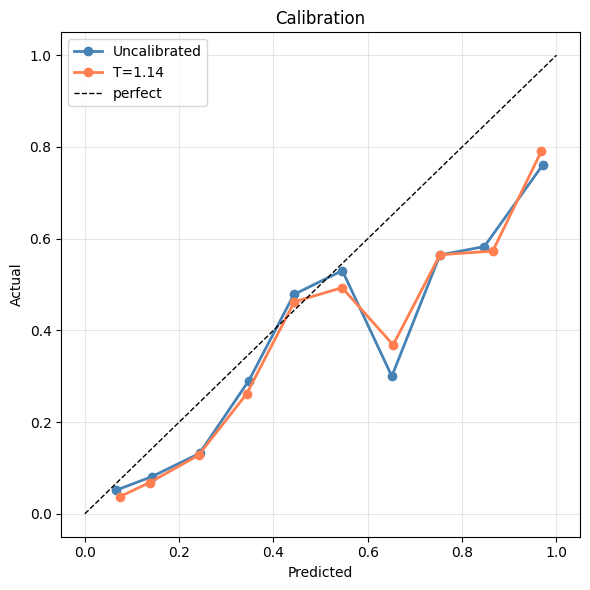

Checkpoint saved: /content/drive/MyDrive/cs159_jeff/libero_pro_results/q_corrector_v2/q_corrector_v2.pt


In [92]:
class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1))
    def forward(self, logits):
        return logits / self.temperature


def fit_temperature(model, val_loader):
    scaler = TemperatureScaler().to(DEVICE)
    model.eval()
    logits_all, labels_all = [], []
    with torch.no_grad():
        for a, cp, obs, y in val_loader:
            a, cp, obs = a.to(DEVICE), cp.to(DEVICE), obs.to(DEVICE)
            logits_all.append(model(a, cp, obs).cpu())
            labels_all.append(y)
    logits_all = torch.cat(logits_all).to(DEVICE)
    labels_all = torch.cat(labels_all).to(DEVICE)
    nll = nn.BCEWithLogitsLoss()
    opt = optim.LBFGS([scaler.temperature], lr=0.01, max_iter=50)
    def closure():
        opt.zero_grad()
        nll(scaler(logits_all), labels_all).backward()
        return nll(scaler(logits_all), labels_all)
    opt.step(closure)
    return scaler


scaler = fit_temperature(model, val_loader)
T_opt  = scaler.temperature.item()
print(f'Temperature: {T_opt:.4f}')

_, probs_raw, labels_val = evaluate(val_loader)
with torch.no_grad():
    val_logits = torch.cat([
        model(b[0].to(DEVICE), b[1].to(DEVICE), b[2].to(DEVICE)).cpu()
        for b in val_loader])
probs_cal = torch.sigmoid(scaler.cpu()(val_logits)).detach().numpy()

fig, ax = plt.subplots(figsize=(6, 6))
for probs, label, c in [(probs_raw, 'Uncalibrated', 'steelblue'),
                         (probs_cal, f'T={T_opt:.2f}', 'coral')]:
    fp, mp = calibration_curve(labels_val, probs, n_bins=10)
    ax.plot(mp, fp, marker='o', lw=2, color=c, label=label)
ax.plot([0,1],[0,1],'k--',lw=1,label='perfect'); ax.legend(); ax.grid(alpha=0.3)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title('Calibration')
plt.tight_layout(); plt.savefig(f'{QC_DIR}/calibration.png', dpi=150); plt.show()

torch.save({'model':           model.state_dict(),
            'temperature':     T_opt,
            'action_feat_dim': train_t[0].shape[1],
            'obs_feat_dim':    train_t[2].shape[1]}, QC_CKPT)
print(f'Checkpoint saved: {QC_CKPT}')


## §10 — Gradient Sanity Check (Offline)

For each λ, apply the Q-corrector gradient to the val set and measure Δf.
Ideal: Δf > 0 on failures (corrector pushes toward success), Δf ≈ 0 on successes.

     λ    Δf success    Δf failure
 0.000        0.0000        0.0000
 0.010        0.0020        0.0019
 0.050        0.0101        0.0094
 0.100        0.0197        0.0189
 0.200        0.0371        0.0376
 0.500        0.0741        0.0892
 1.000        0.1029        0.1571
 1.500        0.1166        0.2060
 2.000        0.1253        0.2441
 2.500        0.1317        0.2758
 3.000        0.1367        0.3028
 3.500        0.1408        0.3261
 4.000        0.1443        0.3463

Ideal: failure Δ > 0, success Δ ≈ 0


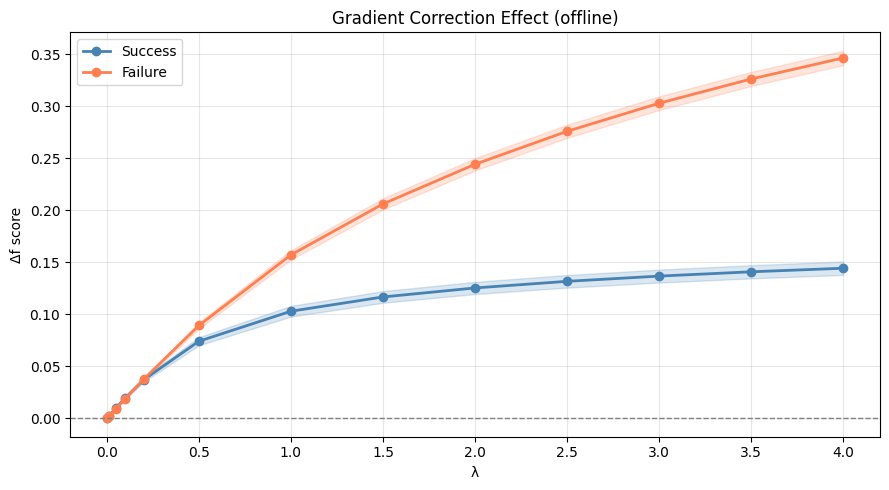

In [98]:
model.eval(); scaler.to(DEVICE)
LAMBDA_VALUES = [0.0, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
results = {lam: {'success': [], 'failure': []} for lam in LAMBDA_VALUES}

for a_orig, cp, obs, y in val_loader:
    a_orig, cp, obs = a_orig.to(DEVICE), cp.to(DEVICE), obs.to(DEVICE)
    a_leaf = a_orig.detach().clone().requires_grad_(True)
    # obs frozen — gradient only through action
    torch.sigmoid(scaler(model(a_leaf, cp, obs.detach()))).sum().backward()
    grad = a_leaf.grad.detach()

    with torch.no_grad():
        for lam in LAMBDA_VALUES:
            a_cor  = a_orig + lam * grad
            delta  = (torch.sigmoid(scaler(model(a_cor,  cp, obs))) -
                      torch.sigmoid(scaler(model(a_orig, cp, obs)))).cpu().numpy()
            yn = y.numpy()
            results[lam]['success'].extend(delta[yn == 1].tolist())
            results[lam]['failure'].extend(delta[yn == 0].tolist())

print(f'{"λ":>6}  {"Δf success":>12}  {"Δf failure":>12}')
for lam in LAMBDA_VALUES:
    print(f'{lam:6.3f}  {np.mean(results[lam]["success"]):>12.4f}  '
          f'{np.mean(results[lam]["failure"]):>12.4f}')
print('\nIdeal: failure Δ > 0, success Δ ≈ 0')

fig, ax = plt.subplots(figsize=(9, 5))
for grp, c, lbl in [('success','steelblue','Success'), ('failure','coral','Failure')]:
    means = [np.mean(results[l][grp]) for l in LAMBDA_VALUES]
    sems  = [np.std(results[l][grp]) / np.sqrt(max(len(results[l][grp]), 1))
             for l in LAMBDA_VALUES]
    ax.plot(LAMBDA_VALUES, means, marker='o', lw=2, color=c, label=lbl)
    ax.fill_between(LAMBDA_VALUES, [m-s for m,s in zip(means,sems)],
                                   [m+s for m,s in zip(means,sems)], alpha=0.2, color=c)
ax.axhline(0, ls='--', color='gray', lw=1)
ax.set_xlabel('λ'); ax.set_ylabel('Δf score'); ax.set_title('Gradient Correction Effect (offline)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f'{QC_DIR}/gradient_sanity.png', dpi=150); plt.show()


## §11 — Live Eval: Baseline + Corrected

Two-pass eval on hard tasks using held-out episodes (ep_idx N_EPISODES_TRAIN..N_EPISODES_TRAIN+N_EPISODES_EVAL-1,
never seen during training).

**Pass A** (λ=0.0): uncorrected baseline — P&P measurement only, no gradient correction.  
**Pass B** (λ=LAMBDA_LIVE): gradient-corrected — same init states + noise seeds as Pass A.

Results in §12 compare the two passes directly (paired by episode).


In [94]:
ckpt    = torch.load(QC_CKPT, map_location=DEVICE)
Q_MODEL = QCorrector(
    action_feat_dim=ckpt['action_feat_dim'],
    obs_feat_dim=ckpt['obs_feat_dim'],
).to(DEVICE)
Q_MODEL.load_state_dict(ckpt['model']); Q_MODEL.eval()
Q_SCALER = TemperatureScaler().to(DEVICE)
Q_SCALER.temperature.data.fill_(ckpt['temperature']); Q_SCALER.eval()

LAMBDA_LIVE_ACTIVE = [0.0]
_E_CHUNK_IDX    = [0]
_E_N_CHUNKS     = [20]
_CORRECTION_LOG = []   # {score, grad_norm, lam} per correction applied

print(f'Corrector loaded. temperature={ckpt["temperature"]:.4f}  ')
print(f'  action_dim={ckpt["action_feat_dim"]}  obs_dim={ckpt["obs_feat_dim"]}')
print(f'Eval episodes: ep_idx {N_EPISODES_TRAIN}..{N_EPISODES_TRAIN + N_EPISODES_EVAL - 1}')


def _refine_with_correction(x_t, s, vfield, cfg, chunk_pos, obs_enc):
    """Run K P&P iterations; optionally apply Q(s,a) gradient correction."""
    adim = cfg.action_dim
    a_hats = []
    x_acc = x_t.clone()
    for _ in range(cfg.num_iterations):
        with torch.no_grad():
            v = vfield(x_acc)
        a_hat = x_acc - s * v
        a_hats.append(a_hat[..., :adim])
        x_acc = (1.0 - s) * a_hat + s * torch.randn_like(x_acc)

    lam = LAMBDA_LIVE_ACTIVE[0]
    if lam > 0.0:
        A     = torch.stack(a_hats, dim=0)      # (K, B, T, adim)
        z_hat = A.mean(dim=0)[0]                # (T, adim)
        cp_t  = torch.tensor([[chunk_pos, float(s)]], dtype=torch.float32, device=DEVICE)
        obs_t = obs_enc.unsqueeze(0)            # (1, d_model) — frozen, no grad

        with torch.enable_grad():
            z_leaf = z_hat.detach().requires_grad_(True)
            z_flat = z_leaf.reshape(1, -1)      # (1, T*adim)
            score  = torch.sigmoid(Q_SCALER(Q_MODEL(z_flat, cp_t, obs_t)))
            if score.item() < 0.5:              # only correct predicted failures
                score.backward()
                grad_z = z_leaf.grad            # (T, adim)
                a_hat_star = a_hat.clone()
                a_hat_star[0, :, :adim] = z_hat + lam * grad_z
                x_acc = (1.0 - s) * a_hat_star + s * torch.randn_like(x_acc)
                _CORRECTION_LOG.append({'score': score.item(),
                                        'grad_norm': grad_z.norm().item(),
                                        'lam': lam})

    return x_acc


@torch.no_grad()
def _sample_actions_eval(self, images, img_masks, tokens, masks,
                          noise=None, num_steps=None, **kwargs):
    if num_steps is None: num_steps = self.config.num_inference_steps
    bsize  = tokens.shape[0]
    device = tokens.device
    if noise is None:
        noise = self.sample_noise(
            (bsize, self.config.chunk_size, self.config.max_action_dim), device)

    from lerobot.policies.pi05.modeling_pi05 import make_att_2d_masks
    prefix_embs, prefix_pad, prefix_att = self.embed_prefix(images, img_masks, tokens, masks)

    # obs encoding for Q(s,a): mean-pool prefix_embs, same as collection
    obs_enc = prefix_embs.mean(dim=1)[0].detach()   # (d_model,) on device

    att_2d  = make_att_2d_masks(prefix_pad, prefix_att)
    pos_ids = torch.cumsum(prefix_pad, dim=1) - 1
    att_4d  = self._prepare_attention_masks_4d(att_2d)
    self.paligemma_with_expert.paligemma.model.language_model.config._attn_implementation = 'eager'
    _, past_kv = self.paligemma_with_expert.forward(
        attention_mask=att_4d, position_ids=pos_ids,
        past_key_values=None, inputs_embeds=[prefix_embs, None], use_cache=True)

    def vfield(x, ts):
        return self.denoise_step(prefix_pad_masks=prefix_pad,
                                 past_key_values=past_kv, x_t=x, timestep=ts)

    cfg   = PnPConfig(step_indices=CORRECTION_STEP_INDICES)
    dt    = -1.0 / num_steps
    x_t   = noise
    chunk_pos = _E_CHUNK_IDX[0] / max(_E_N_CHUNKS[0], 1)

    for step in range(num_steps):
        s  = 1.0 + step * dt
        ts = torch.tensor(s, dtype=torch.float32, device=device).expand(bsize)
        vf = partial(vfield, ts=ts)
        if cfg.step_selected(step, s):
            x_t = _refine_with_correction(x_t, s, vf, cfg, chunk_pos, obs_enc)
        x_t = x_t + dt * vf(x_t)

    _E_CHUNK_IDX[0] += 1
    return x_t


policy.model.sample_actions = types.MethodType(_sample_actions_eval, policy.model)
print('Eval patch installed.')


Corrector loaded. temperature=1.1409  
  action_dim=350  obs_dim=2048
Eval episodes: ep_idx 5..9
Eval patch installed.


In [100]:
N_EPISODES_EVAL = 5

from libero.libero.envs import OffScreenRenderEnv
def _make_eval_rid(suite, task_idx, ep_idx, init_state, lam):
    h   = hashlib.md5(np.asarray(init_state).tobytes()).hexdigest()[:12]
    steps = '_'.join(map(str, sorted(PNP_STEP_INDICES)))
    key = f'{suite}:{task_idx}:{ep_idx}:{h}:eval:steps={steps}:lam={lam}'
    return hashlib.sha256(key.encode()).hexdigest()[:16]



def _run_eval_pass(lam):
    LAMBDA_LIVE_ACTIVE[0] = lam
    label = f'λ={lam}'
    print(f'\n{"="*60}')
    print(f'Pass {label} — {"baseline (no correction)" if lam == 0 else "Q-corrected (hybrid Q(s,a))"}')
    print(f'{"="*60}')

    for suite in SUITES:
        task_suite = bm_dict[suite]()

        for task_idx in range(N_TASKS):
            if (suite, task_idx) not in HARD_TASKS:
                continue
            task        = task_suite.get_task(task_idx)
            init_states = task_suite.get_task_init_states(task_idx)
            task_desc   = task.language
            bddl        = os.path.join(get_libero_path('bddl_files'),
                                       task.problem_folder, task.bddl_file)
            env = OffScreenRenderEnv(
                bddl_file_name=bddl, camera_names=CAMERAS,
                camera_heights=IMG_SIZE, camera_widths=IMG_SIZE,
                has_offscreen_renderer=True, use_camera_obs=True,
                has_renderer=False, reward_shaping=False,
            )

            for ep_idx in range(N_EPISODES_TRAIN, N_EPISODES_TRAIN + N_EPISODES_EVAL):
                init_state = init_states[ep_idx]
                rid = _make_eval_rid(suite, task_idx, ep_idx, init_state, lam)
                if _episode_collected(db_con, 'qc_eval_rollouts', rid):
                    print(f'  skip {suite} t={task_idx} ep={ep_idx} {label}')
                    continue

                env.reset(); policy.reset()
                obs = env.set_init_state(init_state)
                for _ in range(NUM_STEPS_WAIT):
                    obs, _, _, _ = env.step(DUMMY_ACTION)

                _seed = int.from_bytes(
                    hashlib.md5(np.asarray(init_state).tobytes() +
                                str(ep_idx).encode()).digest()[:4], 'big')
                torch.manual_seed(_seed); torch.cuda.manual_seed(_seed)
                _E_CHUNK_IDX[0] = 0

                t0 = _time.time(); success = False; step = 0
                for step in range(MAX_STEPS):
                    batch = preprocess(obs_to_policy(obs, task_desc))
                    with torch.no_grad():
                        action = postprocess(policy.select_action(batch))
                    if isinstance(action, torch.Tensor):
                        action = action.squeeze(0).cpu().numpy()
                    obs, _, done, _ = env.step(action)
                    if env.check_success(): success = True; break
                    if done: break

                elapsed = _time.time() - t0
                h = hashlib.md5(np.asarray(init_state).tobytes()).hexdigest()[:12]
                with db_con:
                    db_con.execute(
                        'INSERT OR IGNORE INTO qc_eval_rollouts VALUES (?,?,?,?,?,?,?,?,?,?,?,?)',
                        (rid, suite, task_idx, ep_idx, task_desc, h,
                         int(success), step + 1, round(elapsed, 3),
                         lam, _json.dumps(list(PNP_STEP_INDICES)),
                         _time.strftime('%Y-%m-%dT%H:%M:%S')))

                print(f'  {"✓" if success else "✗"} {suite} t={task_idx} ep={ep_idx:2d}  '
                      f'{step+1:3d} steps  {elapsed:.1f}s  {label}')

            sr = db_con.execute(
                'SELECT AVG(success) FROM qc_eval_rollouts WHERE suite=? AND task_idx=? AND lambda_=?',
                (suite, task_idx, lam)).fetchone()[0]
            if sr is not None:
                print(f'  → {suite} t={task_idx}  SR={sr:.0%}  {label}')
            env.close()


# _run_eval_pass(0.0)
LAMBDA_LIVE=3.0
_run_eval_pass(LAMBDA_LIVE)
print('\nBoth eval passes complete. Run §12 for results.')



Pass λ=3.0 — Q-corrected (hybrid Q(s,a))
  ✓ libero_object_temp_x0.1 t=0 ep= 5  180 steps  9.8s  λ=3.0
  ✓ libero_object_temp_x0.1 t=0 ep= 6  177 steps  9.8s  λ=3.0
  ✗ libero_object_temp_x0.1 t=0 ep= 7  300 steps  15.5s  λ=3.0
  ✓ libero_object_temp_x0.1 t=0 ep= 8  179 steps  9.5s  λ=3.0
  ✓ libero_object_temp_x0.1 t=0 ep= 9  182 steps  9.6s  λ=3.0
  → libero_object_temp_x0.1 t=0  SR=80%  λ=3.0
  ✓ libero_object_temp_x0.1 t=2 ep= 5  162 steps  8.7s  λ=3.0
  ✓ libero_object_temp_x0.1 t=2 ep= 6  159 steps  8.7s  λ=3.0
  ✓ libero_object_temp_x0.1 t=2 ep= 7  178 steps  9.3s  λ=3.0
  ✗ libero_object_temp_x0.1 t=2 ep= 8  300 steps  15.0s  λ=3.0
  ✗ libero_object_temp_x0.1 t=2 ep= 9  300 steps  14.8s  λ=3.0
  → libero_object_temp_x0.1 t=2  SR=60%  λ=3.0
  ✗ libero_object_temp_x0.1 t=4 ep= 5  300 steps  15.1s  λ=3.0
  ✓ libero_object_temp_x0.1 t=4 ep= 6  127 steps  6.8s  λ=3.0
  ✓ libero_object_temp_x0.1 t=4 ep= 7  125 steps  6.8s  λ=3.0
  ✓ libero_object_temp_x0.1 t=4 ep= 8  123 steps  6.7s

In [101]:
# baseline lambda 0
_run_eval_pass(0.0)


Pass λ=0.0 — baseline (no correction)
  ✓ libero_object_temp_x0.1 t=0 ep= 5  180 steps  9.6s  λ=0.0
  ✓ libero_object_temp_x0.1 t=0 ep= 6  172 steps  9.3s  λ=0.0
  ✗ libero_object_temp_x0.1 t=0 ep= 7  300 steps  15.3s  λ=0.0
  ✓ libero_object_temp_x0.1 t=0 ep= 8  179 steps  9.4s  λ=0.0
  ✓ libero_object_temp_x0.1 t=0 ep= 9  182 steps  9.5s  λ=0.0
  → libero_object_temp_x0.1 t=0  SR=80%  λ=0.0
  ✓ libero_object_temp_x0.1 t=2 ep= 5  165 steps  8.8s  λ=0.0
  ✗ libero_object_temp_x0.1 t=2 ep= 6  300 steps  14.6s  λ=0.0
  ✓ libero_object_temp_x0.1 t=2 ep= 7  169 steps  8.9s  λ=0.0
  ✗ libero_object_temp_x0.1 t=2 ep= 8  300 steps  15.1s  λ=0.0
  ✗ libero_object_temp_x0.1 t=2 ep= 9  300 steps  14.7s  λ=0.0
  → libero_object_temp_x0.1 t=2  SR=40%  λ=0.0
  ✗ libero_object_temp_x0.1 t=4 ep= 5  300 steps  15.0s  λ=0.0
  ✓ libero_object_temp_x0.1 t=4 ep= 6  127 steps  6.8s  λ=0.0
  ✓ libero_object_temp_x0.1 t=4 ep= 7  125 steps  6.7s  λ=0.0
  ✓ libero_object_temp_x0.1 t=4 ep= 8  123 steps  6.6s  

In [ ]:
# #lambda 1.25
# _run_eval_pass(1.25)

In [105]:
# no pnp
policy.model.sample_actions = policy.model._orig_sample_actions
_run_eval_pass(-1.0)  # use lam=-1.0 as sentinel for "no PnP"


Pass λ=-1.0 — Q-corrected (hybrid Q(s,a))
  ✓ libero_object_temp_x0.1 t=0 ep= 5  183 steps  8.8s  λ=-1.0
  ✓ libero_object_temp_x0.1 t=0 ep= 6  177 steps  8.6s  λ=-1.0
  ✗ libero_object_temp_x0.1 t=0 ep= 7  300 steps  13.5s  λ=-1.0
  ✓ libero_object_temp_x0.1 t=0 ep= 8  199 steps  9.5s  λ=-1.0
  ✓ libero_object_temp_x0.1 t=0 ep= 9  186 steps  8.8s  λ=-1.0
  → libero_object_temp_x0.1 t=0  SR=80%  λ=-1.0
  ✗ libero_object_temp_x0.1 t=2 ep= 5  300 steps  13.4s  λ=-1.0
  ✗ libero_object_temp_x0.1 t=2 ep= 6  300 steps  13.2s  λ=-1.0
  ✗ libero_object_temp_x0.1 t=2 ep= 7  300 steps  13.4s  λ=-1.0
  ✗ libero_object_temp_x0.1 t=2 ep= 8  300 steps  13.4s  λ=-1.0
  ✓ libero_object_temp_x0.1 t=2 ep= 9  276 steps  12.6s  λ=-1.0
  → libero_object_temp_x0.1 t=2  SR=20%  λ=-1.0
  ✗ libero_object_temp_x0.1 t=4 ep= 5  300 steps  13.6s  λ=-1.0
  ✓ libero_object_temp_x0.1 t=4 ep= 6  125 steps  6.0s  λ=-1.0
  ✓ libero_object_temp_x0.1 t=4 ep= 7  124 steps  6.0s  λ=-1.0
  ✓ libero_object_temp_x0.1 t=4 ep=

In [109]:
db_con.execute('SELECT lambda_, COUNT(*) FROM qc_eval_rollouts GROUP BY lambda_').fetchall()

[(-1.0, 105), (0.0, 105), (3.0, 105)]

## §12 — Results

In [106]:
results = pd.read_sql('''
    SELECT suite, task_idx, lambda_,
            AVG(success) as sr, COUNT(*) as n
    FROM qc_eval_rollouts
    GROUP BY suite, task_idx, lambda_
    ORDER BY suite, task_idx, lambda_
''', db_con)

# Pivot so each lambda is a column
pivot = results.pivot_table(
    index=['suite', 'task_idx'],
    columns='lambda_',
    values='sr'
).rename(columns={-1.0: 'vanilla', 0.0: 'pnp_base', 3.0: 'pnp_corr'})

pivot['Δ_pnp']  = pivot['pnp_base'] - pivot['vanilla']   # PnP effect
pivot['Δ_corr'] = pivot['pnp_corr'] - pivot['pnp_base']  # correction effect
pivot['Δ_total']= pivot['pnp_corr'] - pivot['vanilla']   # total effect

print(pivot.to_string())
print(f'\nMean Δ_pnp:   {pivot["Δ_pnp"].mean():+.3f}')
print(f'Mean Δ_corr:  {pivot["Δ_corr"].mean():+.3f}')
print(f'Mean Δ_total: {pivot["Δ_total"].mean():+.3f}')

lambda_                           vanilla  pnp_base  pnp_corr  Δ_pnp  Δ_corr  Δ_total
suite                   task_idx                                                     
libero_object_temp_x0.1 0             0.8       0.8       0.8    0.0     0.0      0.0
                        2             0.2       0.4       0.6    0.2     0.2      0.4
                        4             0.6       0.6       0.6    0.0     0.0      0.0
                        5             0.2       0.0       0.0   -0.2     0.0     -0.2
                        6             0.0       0.2       0.2    0.2     0.0      0.2
                        8             0.8       0.4       0.4   -0.4     0.0     -0.4
                        9             0.0       0.0       0.0    0.0     0.0      0.0
libero_object_temp_y0.1 0             0.6       0.6       0.8    0.0     0.2      0.2
                        2             0.4       0.4       0.8    0.0     0.4      0.4
                        4             0.8       0.8   

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [107]:
base = pd.read_sql('SELECT suite, task_idx, AVG(success) as sr_base, COUNT(*) as n_base FROM qc_eval_rollouts WHERE lambda_=0.0 GROUP BY suite, task_idx',
    db_con)
corr = pd.read_sql(
    f'SELECT suite, task_idx, AVG(success) as sr_corr, COUNT(*) as n_corr FROM qc_eval_rollouts WHERE lambda_={LAMBDA_LIVE} GROUP BY suite, task_idx',
    db_con)

tbl = base.merge(corr, on=['suite', 'task_idx'], how='outer')
tbl['delta'] = tbl['sr_corr'] - tbl['sr_base']

tbl['sr_base'] = tbl['sr_base'].map(lambda x: f'{x:.0%}' if pd.notna(x) else 'n/a')
tbl['sr_corr'] = tbl['sr_corr'].map(lambda x: f'{x:.0%}' if pd.notna(x) else 'n/a')
tbl['delta']   = tbl['delta'].map(lambda x: f'{x:+.0%}' if pd.notna(x) else 'n/a')

print(f'Per-task: baseline (λ=0) vs corrected (λ={LAMBDA_LIVE})')
print(tbl[['suite', 'task_idx', 'sr_base', 'sr_corr', 'delta', 'n_base', 'n_corr']].to_string(index=False))

print('\nSuite aggregate')
rows = []
for suite in SUITES:
    b = db_con.execute('SELECT AVG(success) FROM qc_eval_rollouts WHERE suite=? AND lambda_=0.0', [suite]).fetchone()[0]
    c = db_con.execute(f'SELECT AVG(success) FROM qc_eval_rollouts WHERE suite=? AND lambda_={LAMBDA_LIVE}', [suite]).fetchone()[0]
    rows.append({'suite': suite,
                 'baseline': f'{b:.1%}' if b is not None else 'n/a',
                 f'corrected (λ={LAMBDA_LIVE})': f'{c:.1%}' if c is not None else 'n/a',
                 'Δ': f'{c-b:+.1%}' if (b is not None and c is not None) else 'n/a'})
print(pd.DataFrame(rows).set_index('suite').to_string())


Per-task: baseline (λ=0) vs corrected (λ=3.0)
                  suite  task_idx sr_base sr_corr delta  n_base  n_corr
libero_object_temp_x0.1         0     80%     80%   +0%       5       5
libero_object_temp_x0.1         2     40%     60%  +20%       5       5
libero_object_temp_x0.1         4     60%     60%   +0%       5       5
libero_object_temp_x0.1         5      0%      0%   +0%       5       5
libero_object_temp_x0.1         6     20%     20%   +0%       5       5
libero_object_temp_x0.1         8     40%     40%   +0%       5       5
libero_object_temp_x0.1         9      0%      0%   +0%       5       5
libero_object_temp_y0.1         0     60%     80%  +20%       5       5
libero_object_temp_y0.1         2     40%     80%  +40%       5       5
libero_object_temp_y0.1         4     80%     80%   +0%       5       5
libero_object_temp_y0.1         5     40%     40%   +0%       5       5
libero_object_temp_y0.1         7     20%     20%   +0%       5       5
libero_object_temp

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [111]:
# Three-way: vanilla pi05 (lam=-1) | PnP no-corr (lam=0) | PnP corrected (lam=LAMBDA_LIVE)
vanilla = pd.read_sql(
    'SELECT suite, task_idx, AVG(success) as sr_vanilla, COUNT(*) as n_vanilla '
    'FROM qc_eval_rollouts WHERE lambda_=-1.0 GROUP BY suite, task_idx', db_con)

perturb = pd.read_sql(
    'SELECT suite, task_idx, AVG(success) as sr_perturb, COUNT(*) as n_perturb '
    'FROM qc_eval_rollouts WHERE lambda_=0.0 GROUP BY suite, task_idx', db_con)

corrected = pd.read_sql(
    f'SELECT suite, task_idx, AVG(success) as sr_corr, COUNT(*) as n_corr '
    f'FROM qc_eval_rollouts WHERE lambda_={LAMBDA_LIVE} GROUP BY suite, task_idx', db_con)

tbl = vanilla.merge(perturb, on=['suite','task_idx'], how='outer')
tbl = tbl.merge(corrected, on=['suite','task_idx'], how='outer')

tbl['Δ pnp']  = tbl['sr_perturb'] - tbl['sr_vanilla']
tbl['Δ corr'] = tbl['sr_corr']    - tbl['sr_vanilla']

for col in ['sr_vanilla','sr_perturb','sr_corr']:
    tbl[col] = tbl[col].map(lambda x: f'{x:.0%}' if pd.notna(x) else 'n/a')
for col in ['Δ pnp','Δ corr']:
    tbl[col] = tbl[col].map(lambda x: f'{x:+.0%}' if pd.notna(x) else 'n/a')

print(f'Per-task: vanilla | PnP λ=0 | PnP λ={LAMBDA_LIVE}')
print(tbl[['suite','task_idx','sr_vanilla','sr_perturb','sr_corr','Δ pnp','Δ corr','n_vanilla','n_perturb','n_corr']].to_string(index=False))

# Suite aggregate
print('\nSuite aggregate')
rows = []
for suite in SUITES:
    v = db_con.execute('SELECT AVG(success) FROM qc_eval_rollouts WHERE suite=? AND lambda_=-1.0', [suite]).fetchone()[0]
    p = db_con.execute('SELECT AVG(success) FROM qc_eval_rollouts WHERE suite=? AND lambda_=0.0',  [suite]).fetchone()[0]
    c = db_con.execute(f'SELECT AVG(success) FROM qc_eval_rollouts WHERE suite=? AND lambda_={LAMBDA_LIVE}', [suite]).fetchone()[0]
    rows.append({
        'suite':       suite,
        'vanilla':     f'{v:.1%}' if v is not None else 'n/a',
        'pnp λ=0':     f'{p:.1%}' if p is not None else 'n/a',
        f'pnp λ={LAMBDA_LIVE}': f'{c:.1%}' if c is not None else 'n/a',
        'Δ pnp':       f'{p-v:+.1%}' if (p is not None and v is not None) else 'n/a',
        'Δ corr':      f'{c-v:+.1%}' if (c is not None and v is not None) else 'n/a',
    })
print(pd.DataFrame(rows).set_index('suite').to_string())

Per-task: vanilla | PnP λ=0 | PnP λ=3.0
                  suite  task_idx sr_vanilla sr_perturb sr_corr Δ pnp Δ corr  n_vanilla  n_perturb  n_corr
libero_object_temp_x0.1         0        80%        80%     80%   +0%    +0%          5          5       5
libero_object_temp_x0.1         2        20%        40%     60%  +20%   +40%          5          5       5
libero_object_temp_x0.1         4        60%        60%     60%   +0%    +0%          5          5       5
libero_object_temp_x0.1         5        20%         0%      0%  -20%   -20%          5          5       5
libero_object_temp_x0.1         6         0%        20%     20%  +20%   +20%          5          5       5
libero_object_temp_x0.1         8        80%        40%     40%  -40%   -40%          5          5       5
libero_object_temp_x0.1         9         0%         0%      0%   +0%    +0%          5          5       5
libero_object_temp_y0.1         0        60%        60%     80%   +0%   +20%          5          5      

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
